In [ ]:
# STEP 1: Install YOLOv8 (Ultralytics)
!pip install ultralytics

# STEP 2: Clone YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5

# STEP 3: Install YOLOv5 requirements
%cd yolov5
!pip install -r requirements.txt
%cd ..

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.0 MB/s eta 0:00:00
Cloning into 'yolov5'...
remote: Enumerating objects: 17822, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 17822 (delta 15), reused 6 (delta 6), pack-reused 17797 (from 4)
Receiving objects: 100% (17822/17822), 16.96 MiB | 16.86 MiB/s, done.
Resolving deltas: 100% (12141/12141), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
/content


In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: Tesla T4


In [ ]:
# STEP 1: Download dataset
import requests, zipfile, os

url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/signature.zip"
r = requests.get(url)
open("signature.zip", "wb").write(r.content)

# STEP 2: Extract dataset
with zipfile.ZipFile("signature.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets")

# STEP 3: Verify structure
os.listdir("datasets")

['labels', 'LICENSE.txt', 'images', 'signature.yaml']

In [ ]:
# STEP 1: Create subset folder
import shutil, random, os

source_images = "datasets/images/train"
source_labels = "datasets/labels/train"

target_images = "datasets/signature/images/train_subset"
target_labels = "datasets/signature/labels/train_subset"

os.makedirs(target_images, exist_ok=True)
os.makedirs(target_labels, exist_ok=True)

# STEP 2: Select max 500 images and their corresponding labels
images = os.listdir(source_images)
subset = random.sample(images, min(500, len(images)))

# STEP 3: Copy selected images and their labels
for img_file in subset:
    # Copy image
    shutil.copy(os.path.join(source_images, img_file), target_images)

    # Copy corresponding label file (assuming .txt extension and same name as image)
    label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt') # Handle common image extensions
    shutil.copy(os.path.join(source_labels, label_file), target_labels)


In [ ]:
yaml_content = """
train: /content/datasets/signature/images/train_subset
val: /content/datasets/images/val

nc: 1
names: ['signature']
"""

with open("/content/datasets/signature.yaml", "w") as f:
    f.write(yaml_content)

print("signature.yaml updated successfully")

signature.yaml updated successfully


In [ ]:
!python yolov5/train.py \
  --img 640 \
  --batch 16 \
  --epochs 50 \
  --data /content/datasets/signature.yaml \
  --weights yolov5/yolov5s.pt \
  --device 0 \
  --name yolov5_signature

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-02-26 13:36:01.125295: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772112961.146238     443 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772112961.153079     443 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [ ]:
# STEP 1: Import YOLO
from ultralytics import YOLO
import yaml
import os

# STEP 2: Define YAML content with absolute paths
yaml_content = {
    'train': '/content/datasets/signature/images/train_subset',
    'val': '/content/datasets/images/val',
    'nc': 1,
    'names': ['signature']
}

yaml_path = '/content/datasets/signature.yaml'

# Write updated YAML file
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("signature.yaml updated successfully ✅")

# STEP 3: Load pretrained YOLOv8 model
model_v8 = YOLO("yolov8n.pt")

# STEP 4: Train model on GPU
model_v8.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,                # Force GPU
    name="yolov8_signature"
)

# STEP 5: Save best weights path
v8_weights = "/content/runs/detect/yolov8_signature/weights/best.pt"

print("Best model saved at:", v8_weights)

signature.yaml updated successfully ✅
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/signature.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_signature, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [ ]:
v5_weights = "/content/yolov5/runs/train/yolov5_signature/weights/best.pt"

!python yolov5/val.py \
  --data /content/datasets/signature.yaml \
  --weights "$v5_weights" \
  --device 0

val: data=/content/datasets/signature.yaml, weights=['/content/yolov5/runs/train/yolov5_signature/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=yolov5/runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/datasets/labels/val... 35 images, 0 backgrounds, 0 corrupt: 100% 35/35 [00:00<00:00, 959.96it/s]
val: New cache created: /content/datasets/labels/val.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 2/2 [00:01<00:00,  1.07it/s]
                   all         35         35      0.997          1      0.995      0.941
Speed: 0.1ms pre-

In [ ]:
from ultralytics import YOLO

v8_weights = "/content/runs/detect/yolov8_signature/weights/best.pt"

model_v8 = YOLO(v8_weights)

metrics = model_v8.val(
    data="/content/datasets/signature.yaml",
    device=0
)

v8_map = metrics.box.map

print("YOLOv8 mAP:", v8_map)

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1939.1±756.0 MB/s, size: 65.4 KB)
val: Scanning /content/datasets/labels/val... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 2.4Kit/s 0.0s
val: New cache created: /content/datasets/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.1it/s 1.5s
                   all         35         35      0.999          1      0.995      0.974
Speed: 7.1ms preprocess, 4.0ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/runs/detect/val2
YOLOv8 mAP: 0.9738100408596588


In [ ]:
import os
i+mport numpy as np
import torch
import cv2
from ultralytics import YOLO
from tqdm import tqdm

model_v8 = YOLO(v8_weights)
# Corrected path for v5_weights
v5_weights = "/content/yolov5/runs/train/yolov5_signature/weights/best.pt"
model_v5 = torch.hub.load('ultralytics/yolov5', 'custom', path=v5_weights)

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

def ensemble_predict(image_path):

    r8 = model_v8(image_path)[0]
    boxes8 = r8.boxes.xyxy.cpu().numpy() if len(r8.boxes) > 0 else np.empty((0, 4))
    scores8 = r8.boxes.conf.cpu().numpy() if len(r8.boxes) > 0 else np.empty((0,))

    r5 = model_v5(image_path)
    if len(r5.xyxy[0]) > 0:
        boxes5 = r5.xyxy[0][:, :4].cpu().numpy()
        scores5 = r5.xyxy[0][:, 4].cpu().numpy()
    else:
        boxes5 = np.empty((0, 4))
        scores5 = np.empty((0,))

    boxes = np.vstack((boxes8, boxes5))
    scores = np.hstack((scores8, scores5))

    if len(boxes) == 0:
        return [], []

    boxes_xywh = []
    for box in boxes:
        x1, y1, x2, y2 = box
        boxes_xywh.append([x1, y1, x2 - x1, y2 - y1])

    indices = cv2.dnn.NMSBoxes(
        boxes_xywh,
        scores.tolist(),
        score_threshold=0.25,
        nms_threshold=0.45
    )

    if len(indices) > 0:
        indices = indices.flatten()
        return boxes[indices], scores[indices]
    else:
        return [], []

val_img_dir = "/content/datasets/images/val"
val_label_dir = "/content/datasets/labels/val"

all_scores = []
all_tp = []
total_gt = 0

for img_name in tqdm(os.listdir(val_img_dir)):

    img_path = os.path.join(val_img_dir, img_name)
    label_path = os.path.join(val_label_dir, img_name.replace(".jpg", ".txt"))

    boxes_pred, scores_pred = ensemble_predict(img_path)

    # Load ground truth
    if os.path.exists(label_path):
        gt_data = np.loadtxt(label_path).reshape(-1, 5)
        total_gt += len(gt_data)
    else:
        gt_data = np.empty((0,5))

    matched = []

    for i, pred_box in enumerate(boxes_pred):
        best_iou = 0
        best_gt = -1

        for j, gt in enumerate(gt_data):
            img = cv2.imread(img_path)
            h, w = img.shape[:2]

            _, x, y, bw, bh = gt
            x1 = (x - bw/2) * w
            y1 = (y - bh/2) * h
            x2 = (x + bw/2) * w
            y2 = (y + bh/2) * h
            gt_box = [x1, y1, x2, y2]

            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt = j

        if best_iou >= 0.5 and best_gt not in matched:
            all_tp.append(1)
            matched.append(best_gt)
        else:
            all_tp.append(0)

        all_scores.append(scores_pred[i])

all_scores = np.array(all_scores)
all_tp = np.array(all_tp)

indices = np.argsort(-all_scores)
all_tp = all_tp[indices]

fp = 1 - all_tp
tp_cum = np.cumsum(all_tp)
fp_cum = np.cumsum(fp)

recalls = tp_cum / total_gt
precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

ap = np.trapz(precisions, recalls)

print("Ensemble mAP@0.5:", ap)

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2026-2-26 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
  0%|          | 0/35 [00:00<?, ?it/s]


image 1/1 /content/datasets/images/val/Frame_422.jpg: 384x640 1 signature, 6.8ms
Speed: 2.0ms preprocess, 6.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  3%|▎         | 1/35 [00:00<00:03,  9.81it/s]


image 1/1 /content/datasets/images/val/Frame_342.jpg: 384x640 1 signature, 6.5ms
Speed: 2.2ms preprocess, 6.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/datasets/images/val/Frame_346.jpg: 384x640 1 signature, 6.5ms
Speed: 1.9ms preprocess, 6.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  9%|▊         | 3/35 [00:00<00:02, 15.10it/s]

...

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
 97%|█████████▋| 34/35 [00:01<00:00, 16.31it/s]


image 1/1 /content/datasets/images/val/Frame_440.jpg: 384x640 1 signature, 31.5ms
Speed: 2.8ms preprocess, 31.5ms inference, 7.4ms postprocess per image at shape (1, 3, 384, 640)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
100%|██████████| 35/35 [00:02<00:00, 16.48it/s]

Ensemble mAP@0.5: 0.9714284676430117



/tmp/ipython-input-190/3193782587.py:128: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precisions, recalls)


In [ ]:
import random
import os

val_dir = "/content/datasets/images/val"

val_images = [f for f in os.listdir(val_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

sample_img = os.path.join(val_dir, random.choice(val_images))

print("Testing image:", sample_img)

boxes, scores = ensemble_predict(sample_img)

if len(boxes) > 0:
    print("Final Boxes:\n", boxes)
    print("Final Scores:\n", scores)
else:
    print("No detections from ensemble.")

Testing image: /content/datasets/images/val/Frame_134.jpg

image 1/1 /content/datasets/images/val/Frame_134.jpg: 384x640 1 signature, 16.8ms
Speed: 6.9ms preprocess, 16.8ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)
Final Boxes:
 [[     639.91      312.19      1341.6      1078.3]]
Final Scores:
 [    0.97652]


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
v5_map = 0.995      # mAP50
v8_map = 0.995      # mAP50
ensemble_map = ap  # mAP@0.5

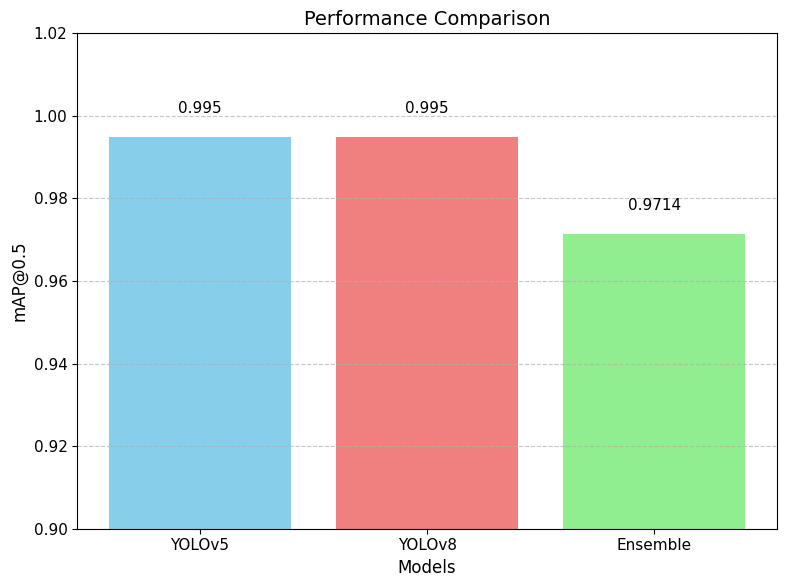

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt

models = ["YOLOv5", "YOLOv8", "Ensemble"]
maps = [v5_map, v8_map, ensemble_map]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, maps, color=['skyblue', 'lightcoral', 'lightgreen'])

plt.xlabel("Models", fontsize=12)
plt.ylabel("mAP@0.5", fontsize=12)
plt.title("Performance Comparison", fontsize=14)
plt.ylim(0.9, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom') # Display mAP values on bars

plt.tight_layout()
plt.show()